Notebook illustrating the IF mining method of the paper. 

We only consider data from ILL18 for 2018. 

Note: Results may differ from the paper since we are only using data from 2018 and working with the final catalog only.

In [90]:
import obspy
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from joblib import dump, load

from seismicif.datamod.loading_utils import (
    preproc_flow_annotations,
    extract_split_flows,
)
from seismicif.datamod.trigger_utils import stream_trigger_detections
from seismicif.isolation_forest import train_if, compute_scores, create_if_stream
from seismicif.metrics import (
    iou,
    est_thresholds,
    compute_statistics,
    extract_valid_segments,
)

First we train an isolation forest to the miniseed files contained in the folder "../data/XP/2018/ILL18/HHZ.D".

Note that the suffixes contain the day of the year, which we use to sort the files.

In [91]:
folder = "../data/XP/2018/ILL18/EHZ.D/"
stream_paths = [folder + f for f in os.listdir(folder) if not f.startswith("._")]
stream_paths = np.array(sorted(stream_paths, key=lambda f: int(f.rsplit(".", 1)[-1])))

Now we train the isolation forest. This will take a couple of minutes.

In [92]:
try:
    if_mod = load("../output/XP/if/models/ILL18_illustration.joblib")

except (FileNotFoundError, OSError):
    if_mod = train_if(stream_paths)
    dump(if_mod, "../output/XP/if/models/ILL18_illustration.joblib")

Next we run the trained isolation forest over the training and/or testing period and extract time series of the anomaly scores.

Note. The miniseed files we worked with correspond to a given day. When we extract sliding windows, there can be a small amount of the waveform towards the end of the day that is not accessed, because it is not sufficiently long to form a full window. In such cases the waveform of the next day (if available) is appended to this residual waveform.

The function below takes a few minutes to run if the scores have not been stored.


In [93]:
try:
    scores_df = pd.read_csv(
        "../output/XP/if/scores/ILL18_illustration.csv", index_col=0
    )
    # The conversion to UTCDateTime takes  few seconds
    scores_df["start"] = [obspy.UTCDateTime(str(i)) for i in scores_df["start"]]
    scores_df["stop"] = [obspy.UTCDateTime(str(i)) for i in scores_df["stop"]]

except (FileNotFoundError, OSError):
    scores_df = compute_scores(stream_paths, if_mod)
    scores_df.to_csv("../output/XP/if/scores/ILL18_illustration.csv")

The scores_df dataframe is then converted into an obspy stream. Takes a few seconds for the conversion.

In [94]:
if_st = create_if_stream(scores_df, station="ILL18", sr=0.02, network="XP")

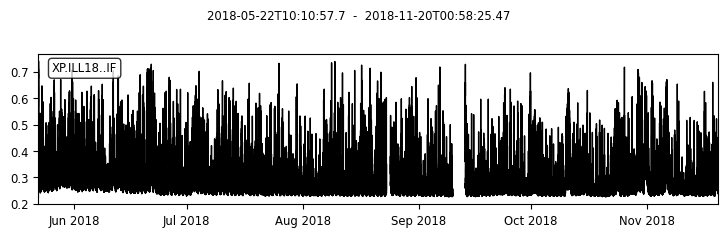

In [95]:
if_st.plot()
plt.show()

Now that we have the isolation forest obspy stream we need to calibrate the onset- and offset thresholds of the IF trigger. For this we only consider days with at least one segment in the catalog.

In [96]:
flows = preproc_flow_annotations(
    pd.read_csv("../catalogs/XP/flow_catalog.csv", index_col=0)
)
lower_conf_flows, high_conf_flows, all_flows = extract_split_flows(
    flows, "ILL18", 2018, 2018
)

# extract days with at least one segment in the catalog
# and create a stream with all segments for each day
dates = []
for i in range(all_flows.shape[0]):
    dates.append(all_flows["start"].iloc[i].date)
    dates.append(all_flows["stop"].iloc[i].date)
dates = np.array(dates)
dates = np.unique(dates)

st = obspy.Stream()
for dt in dates:
    start = obspy.UTCDateTime(f"{dt}T00:00:00")
    end = obspy.UTCDateTime(f"{dt}T23:59:59.999999")
    st += if_st.copy().trim(start, end)

# capture the segments in the catalog as well as possible
onset_grid = np.array([0.55, 0.60, 0.65, 0.70])
offset_grid = np.array([0.50, 0.55, 0.60, 0.65])

iou_table = np.zeros([len(onset_grid), len(offset_grid)])
for i in range(onset_grid.shape[0]):
    for j in range(offset_grid.shape[0]):
        if onset_grid[i] < offset_grid[j]:
            continue

        segments = stream_trigger_detections(st, onset_grid[i], offset_grid[j])
        inter, union, _ = iou(segments, all_flows)
        iou_table[i, j] = inter[-1] / union[-1]

max_idx = np.unravel_index(np.argmax(iou_table), iou_table.shape)
onset_thres, offset_thres = onset_grid[max_idx[0]], offset_grid[max_idx[1]]

print(f"max iou: {100 * iou_table[max_idx]:.2f}%")

# extract and save the segments
if_segments = stream_trigger_detections(if_st, onset_thres, offset_thres)
if_segments.to_csv("../output/XP/if/segments/ILL18_illustration.csv")

max iou: 62.05%


When calibrating the minimum detection length and score thresholds we compare (a) only detections overlapping with a high confidence segment or no lower-confidence segments with (b) high confidence segments.

In [97]:
valid_segments = extract_valid_segments(if_segments, lower_conf_flows, high_conf_flows)
iou_val, min_len, score_thres = est_thresholds(valid_segments, high_conf_flows)
print(f"detection iou: {100 * iou_val:.2f}%")

detection iou: 58.44%


In [98]:
# printout of all detections
detections = if_segments.copy()
start_times = np.array([pd.to_datetime(str(i)) for i in detections["start"]])
end_times = np.array([pd.to_datetime(str(i)) for i in detections["stop"]])
det_lens = np.array([i.total_seconds() for i in end_times - start_times])
detections = detections.assign(det_lens=det_lens)
detections = detections[
    (detections["scores"] > score_thres) & (detections["det_lens"] > min_len)
].reset_index(drop=True)
print(detections.head())

                         start                         stop    scores  \
0  2018-07-25T16:50:03.520019Z  2018-07-25T17:29:13.520019Z  0.731804   
1  2018-10-29T15:15:55.470000Z  2018-10-29T16:58:25.470000Z  0.708447   
2  2018-06-11T10:15:53.740003Z  2018-06-11T11:09:13.740003Z  0.703170   
3  2018-10-29T14:25:05.470000Z  2018-10-29T15:05:55.470000Z  0.693953   
4  2018-06-12T17:57:33.740003Z  2018-06-12T19:24:13.740003Z  0.684732   

   det_lens  
0    2350.0  
1    6150.0  
2    3200.0  
3    2450.0  
4    5200.0  
